<a href="https://colab.research.google.com/github/leancorv/AnatomiaGolMessi/blob/main/messi_anatomia_gol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚽ La Anatomía de un Gol de Messi
### Análisis exploratorio de 900+ goles a lo largo de su carrera

**Objetivo:** Entender *cómo* y *cuándo* mete goles Messi — más allá del simple conteo por temporada.  
**Dataset:** Registro completo de goles desde 2005 hasta 2026.  
**Preguntas que guían el análisis:**
- ¿En qué minuto del partido es más letal?
- ¿Cómo evolucionó su perfil de goleador a lo largo de su carrera?
- ¿Cómo cambió su juego al pasar de Barcelona → PSG → Inter Miami?
- ¿En qué competiciones es más efectivo?
- ¿Qué rol tienen los penales y tiros libres vs goles de juego abierto?

## 0. Instalación y configuración

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo global para todas las visualizaciones
plt.rcParams['figure.facecolor'] = '#0e1117'
plt.rcParams['axes.facecolor'] = '#0e1117'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#cccccc'
plt.rcParams['xtick.color'] = '#cccccc'
plt.rcParams['ytick.color'] = '#cccccc'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['grid.color'] = '#222222'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'sans-serif'

GOLD = '#f5c518'
BLUE = '#4a90d9'
RED  = '#e05252'
GREEN = '#5cb85c'

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Carga y primera exploración del dataset

In [21]:
# Carga directa desde Google Sheets (público)
SHEET_ID = '1-MQcfFuBED9VTE1vsruclxFfYNlSkQmf422NaY7Xb84'
url = f'https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv'

df_raw = pd.read_csv(url)

print(f'📊 Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')
df_raw.head()

📊 Filas: 903 | Columnas: 12


,Índice,Fecha,Equipo Local,Resultado,Equipo Visitante,Marcador,Tipo,Cómo,Competición,Camiseta,Minuto,Video
0,903,4-4-2026,Inter Miami CF,2-2,Austin FC,1-1,Gol de campo,Cabeza,Major League Soccer,10,11,https://www.youtube.com/watch?v=eB-jkuk-G_E
1,902,31-3-2026,Argentina,5-0,Zambia,2-0,Gol de campo,Pie Izquierdo,Amistoso Internacional,10,43,https://www.youtube.com/watch?v=i6MxuUIzVQM
2,901,22-3-2026,New York City FC,2-3,Inter Miami CF,2-2,Tiro libre,Pie Izquierdo,Major League Soccer,10,61,https://www.youtube.com/watch?v=4a7OHoGguZY
3,900,18-3-2026,Inter Miami CF,1-1,Nashville SC,1-0,Gol de campo,Pie Izquierdo,NAMConcacaf Champions Cup,10,7,https://www.youtube.com/watch?v=jujbw3bIGFU
4,899,7-3-2026,DC United,1-2,Inter Miami CF,0-2,Gol de campo,Pie Izquierdo,Major League Soccer,10,27,https://www.youtube.com/watch?v=ilsqlJKSkJY


In [22]:
# Información general del dataset
print('=== Tipos de datos ===')
print(df_raw.dtypes)
print()
print('=== Valores nulos ===')
print(df_raw.isnull().sum())
print()
print('=== Estadísticas de columna Minuto ===')
print(df_raw['Minuto'].describe())

=== Tipos de datos ===
Índice               int64
Fecha               object
Equipo Local        object
Resultado           object
Equipo Visitante    object
Marcador            object
Tipo                object
Cómo                object
Competición         object
Camiseta             int64
Minuto              object
Video               object
dtype: object

=== Valores nulos ===
Índice                0
Fecha                 0
Equipo Local          0
Resultado             0
Equipo Visitante      0
Marcador              0
Tipo                278
Cómo                  0
Competición           0
Camiseta              0
Minuto                0
Video               655
dtype: int64

=== Estadísticas de columna Minuto ===
count     903
unique    102
top        87
freq       22
Name: Minuto, dtype: object


## 2. Limpieza de datos
Antes de analizar, hay que asegurarse de que los datos estén en el formato correcto.

In [23]:
df = df_raw.copy()

# ── Fechas ────────────────────────────────────────────────────────────────────
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True, errors='coerce')
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month

# ── Temporadas (agosto a julio, como en el fútbol europeo) ───────────────────
df['Temporada'] = df['Fecha'].apply(
    lambda d: f"{d.year}/{str(d.year+1)[-2:]}" if d.month >= 8
    else f"{d.year-1}/{str(d.year)[-2:]}"
    if pd.notnull(d) else None
)

# ── Minuto numérico (manejar casos como '90+3', '45+5') ─────────────────────
def parse_minuto(m):
    m = str(m).replace(' ', '')
    if '+' in m:
        parts = m.split('+')
        try: return int(parts[0]) + int(parts[1])
        except: return None
    try: return int(m)
    except: return None

df['Minuto_num'] = df['Minuto'].apply(parse_minuto)

# ── Etiquetar mitad del partido ───────────────────────────────────────────────
df['Mitad'] = df['Minuto_num'].apply(
    lambda m: 'Primer tiempo' if m is not None and m <= 45
    else ('Segundo tiempo' if m is not None else 'Desconocido')
)

# ── Club / Era de su carrera ─────────────────────────────────────────────────
def era(equipo, año):
    if 'Barcelona' in str(equipo): return 'FC Barcelona'
    if 'Paris' in str(equipo) or 'PSG' in str(equipo): return 'PSG'
    if 'Miami' in str(equipo): return 'Inter Miami'
    if 'Argentina' in str(equipo): return 'Selección Argentina'
    return 'Otro'

df['Era'] = df.apply(lambda r: era(r['Equipo Local'], r['Año']), axis=1)
# Corregir era para cuando juega de visitante con el club
df.loc[df['Era'] == 'Otro', 'Era'] = df.loc[df['Era'] == 'Otro'].apply(
    lambda r: era(r['Equipo Visitante'], r['Año']), axis=1
)

# ── Tipo de gol simplificado ──────────────────────────────────────────────────
def tipo_simple(t):
    if pd.isna(t): return 'Gol de campo'
    t = str(t).strip()
    if t in ['Penal', 'Tiro libre']: return t
    return 'Gol de campo'

df['Tipo_simple'] = df['Tipo'].apply(tipo_simple)

# ── Normalizar pie ────────────────────────────────────────────────────────────
df['Pie'] = df['Cómo'].str.strip().str.title()
df['Pie'] = df['Pie'].replace({
    'Pie Izquierdo': 'Pie izquierdo',
    'Pie Derecho': 'Pie derecho',
})

print(f'✅ Limpieza completa. Dataset final: {df.shape[0]} goles')
df[['Fecha','Temporada','Era','Minuto_num','Mitad','Tipo_simple','Pie']].head(10)

✅ Limpieza completa. Dataset final: 903 goles


,Fecha,Temporada,Era,Minuto_num,Mitad,Tipo_simple,Pie
0,2026-04-04,2025/26,Inter Miami,11,Primer tiempo,Gol de campo,Cabeza
1,2026-03-31,2025/26,Selección Argentina,43,Primer tiempo,Gol de campo,Pie izquierdo
2,2026-03-22,2025/26,Inter Miami,61,Segundo tiempo,Tiro libre,Pie izquierdo
3,2026-03-18,2025/26,Inter Miami,7,Primer tiempo,Gol de campo,Pie izquierdo
4,2026-03-07,2025/26,Inter Miami,27,Primer tiempo,Gol de campo,Pie izquierdo
5,2026-03-01,2025/26,Inter Miami,90,Segundo tiempo,Tiro libre,Pie izquierdo
6,2026-03-01,2025/26,Inter Miami,57,Segundo tiempo,Gol de campo,Pie izquierdo
7,2025-11-23,2025/26,Inter Miami,19,Primer tiempo,Gol de campo,Cabeza
8,2025-11-14,2025/26,Selección Argentina,82,Segundo tiempo,Gol de campo,Pie izquierdo
9,2025-11-08,2025/26,Inter Miami,39,Primer tiempo,Gol de campo,Pie izquierdo


## 3. Análisis 1 — Evolución de goles por temporada
El panorama general: cómo fue su producción año a año.

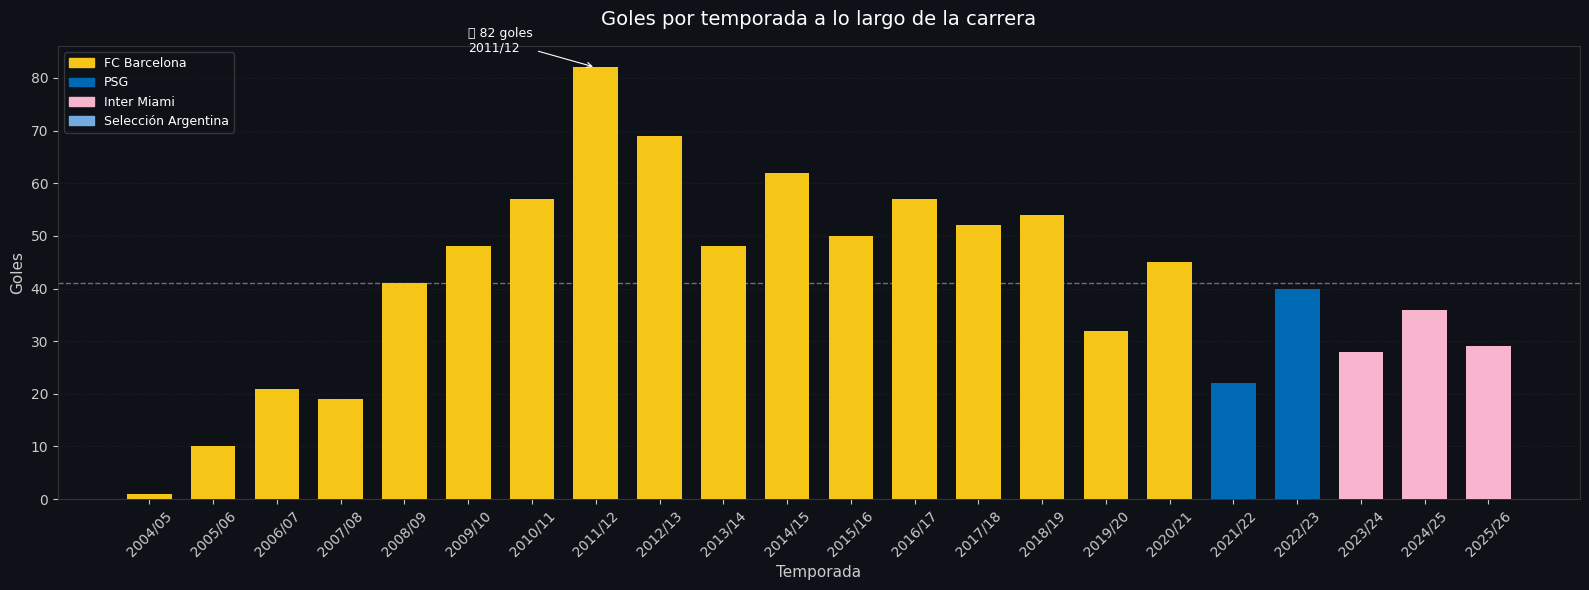

💾 Guardado como goles_por_temporada.png


In [24]:
goles_temp = df.groupby('Temporada').size().reset_index(name='Goles')

# Asignar colores por era
era_por_temporada = df.groupby('Temporada')['Era'].agg(lambda x: x.value_counts().index[0]).reset_index()
era_por_temporada.columns = ['Temporada', 'Era_principal']
goles_temp = goles_temp.merge(era_por_temporada, on='Temporada')

color_map = {'FC Barcelona': GOLD, 'PSG': '#0069b4', 'Inter Miami': '#f7b5cd', 'Selección Argentina': '#74acdf', 'Otro': '#888'}
colores = goles_temp['Era_principal'].map(color_map)

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(goles_temp['Temporada'], goles_temp['Goles'], color=colores, width=0.7, zorder=3)

# Línea de media
media = goles_temp['Goles'].mean()
ax.axhline(media, color='#ffffff', linewidth=1, linestyle='--', alpha=0.4, label=f'Media: {media:.0f} goles/temporada')

# Anotaciones de picos
max_row = goles_temp.loc[goles_temp['Goles'].idxmax()]
ax.annotate(f"🏆 {int(max_row['Goles'])} goles\n{max_row['Temporada']}",
            xy=(max_row.name, max_row['Goles']),
            xytext=(max_row.name - 2, max_row['Goles'] + 3),
            fontsize=9, color='white', arrowprops=dict(arrowstyle='->', color='white', lw=0.8))

ax.set_title('Goles por temporada a lo largo de la carrera', fontsize=14, pad=15, color='white')
ax.set_xlabel('Temporada', fontsize=11)
ax.set_ylabel('Goles', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(axis='y', zorder=0)

# Leyenda de eras
from matplotlib.patches import Patch
eras_legend = [Patch(color=v, label=k) for k, v in color_map.items() if k != 'Otro']
ax.legend(handles=eras_legend, loc='upper left', fontsize=9, framealpha=0.2)

plt.tight_layout()
plt.savefig('goles_por_temporada.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print('💾 Guardado como goles_por_temporada.png')

## 4. Análisis 2 — El reloj de Messi: ¿en qué minuto es más letal?
Distribución de goles por franja de minutos.


🔍 Franja con más goles: 76-90 (183 goles)
📊 Goles en el primer tiempo: 397 (44.0%)
📊 Goles en el segundo tiempo: 506 (56.0%)


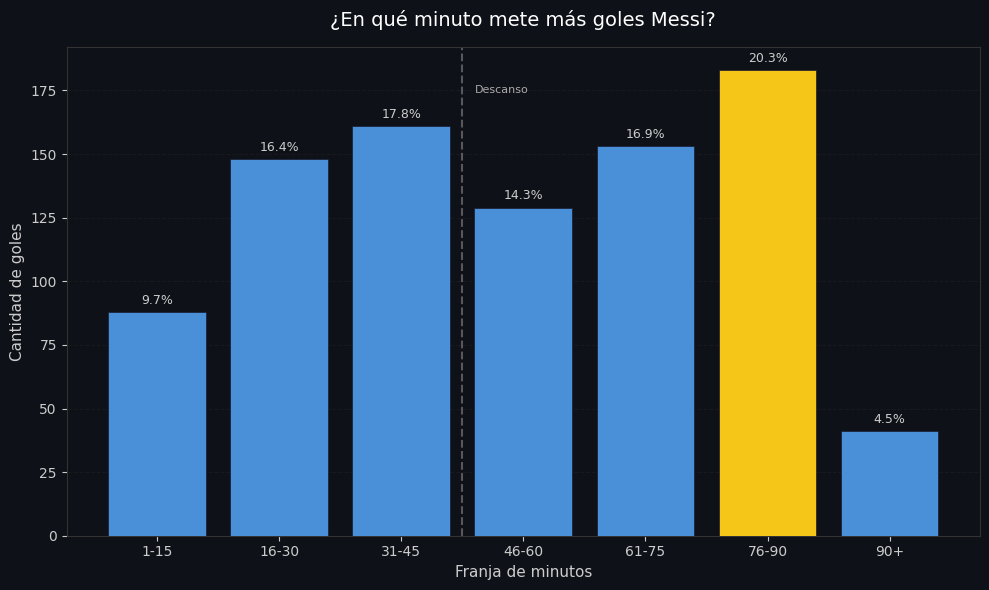

In [13]:
df_min = df.dropna(subset=['Minuto_num']).copy()
df_min['Franja'] = pd.cut(df_min['Minuto_num'],
                           bins=[0,15,30,45,60,75,90,120],
                           labels=['1-15','16-30','31-45','46-60','61-75','76-90','90+'])

conteo = df_min['Franja'].value_counts().sort_index()
pct = (conteo / conteo.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [GOLD if v == conteo.max() else BLUE for v in conteo.values]
bars = ax.bar(conteo.index.astype(str), conteo.values, color=bar_colors, edgecolor='#1a1a2e', linewidth=0.5, zorder=3)

for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{p}%', ha='center', va='bottom', fontsize=9, color='#cccccc')

ax.axvline(x=2.5, color='#ffffff', linewidth=1.5, linestyle='--', alpha=0.3, label='Descanso')
ax.text(2.6, conteo.max() * 0.95, 'Descanso', fontsize=8, color='#aaaaaa')

ax.set_title('¿En qué minuto mete más goles Messi?', fontsize=14, pad=15)
ax.set_xlabel('Franja de minutos', fontsize=11)
ax.set_ylabel('Cantidad de goles', fontsize=11)
ax.grid(axis='y', zorder=0)

franja_max = conteo.idxmax()
print(f'\n🔍 Franja con más goles: {franja_max} ({conteo[franja_max]} goles)')
print(f'📊 Goles en el primer tiempo: {conteo[:3].sum()} ({conteo[:3].sum()/conteo.sum()*100:.1f}%)')
print(f'📊 Goles en el segundo tiempo: {conteo[3:].sum()} ({conteo[3:].sum()/conteo.sum()*100:.1f}%)')

plt.tight_layout()
plt.savefig('goles_por_minuto.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()

## 5. Análisis 3 — La zurda de Dios: ¿cómo mete los goles?
Distribución por pie/cabeza, y cómo evolucionó con los años.

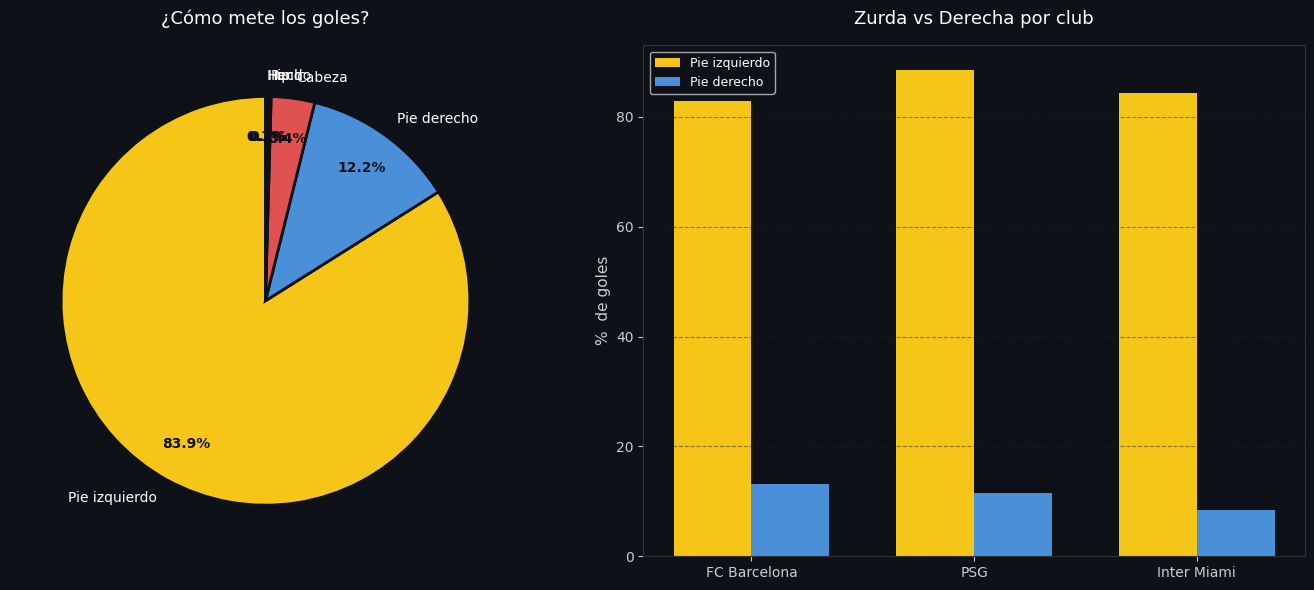


🦶 Goles de zurda: 83.9%
🦶 Goles de derecha: 12.2%
🦶 Goles de cabeza: 3.4%


In [25]:
conteo_pie = df['Pie'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Gráfico de torta ──────────────────────────────────────────────────────────
ax1 = axes[0]
pie_colors = [GOLD, BLUE, RED, GREEN, '#888']
wedges, texts, autotexts = ax1.pie(
    conteo_pie.values, labels=conteo_pie.index,
    autopct='%1.1f%%', colors=pie_colors[:len(conteo_pie)],
    startangle=90, pctdistance=0.8,
    wedgeprops={'edgecolor': '#0e1117', 'linewidth': 2}
)
for text in texts: text.set_color('white')
for autotext in autotexts: autotext.set_color('#0e1117'); autotext.set_fontweight('bold')
ax1.set_title('¿Cómo mete los goles?', fontsize=13, pad=15)

# ── Evolución pie izquierdo vs derecho por era ────────────────────────────────
ax2 = axes[1]
era_order = ['FC Barcelona', 'PSG', 'Inter Miami']
df_club = df[df['Era'].isin(era_order)]
pivot_pie = df_club.groupby(['Era', 'Pie']).size().unstack(fill_value=0)
pivot_pct = pivot_pie.div(pivot_pie.sum(axis=1), axis=0) * 100

if 'Pie izquierdo' in pivot_pct.columns and 'Pie derecho' in pivot_pct.columns:
    x = np.arange(len(era_order))
    w = 0.35
    pivot_pct_ordered = pivot_pct.reindex(era_order)
    ax2.bar(x - w/2, pivot_pct_ordered['Pie izquierdo'], width=w, label='Pie izquierdo', color=GOLD)
    ax2.bar(x + w/2, pivot_pct_ordered['Pie derecho'], width=w, label='Pie derecho', color=BLUE)
    ax2.set_xticks(x)
    ax2.set_xticklabels(era_order)
    ax2.set_ylabel('%  de goles', fontsize=11)
    ax2.set_title('Zurda vs Derecha por club', fontsize=13, pad=15)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', zorder=0)

plt.tight_layout()
plt.savefig('goles_por_pie.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()

pie_pct = conteo_pie / conteo_pie.sum() * 100
print(f'\n🦶 Goles de zurda: {pie_pct.get("Pie izquierdo", 0):.1f}%')
print(f'🦶 Goles de derecha: {pie_pct.get("Pie derecho", 0):.1f}%')
print(f'🦶 Goles de cabeza: {pie_pct.get("Cabeza", 0):.1f}%')

## 6. Análisis 4 — Penales, tiros libres y goles de campo
¿Creció su dependencia de situaciones a balón parado con los años?

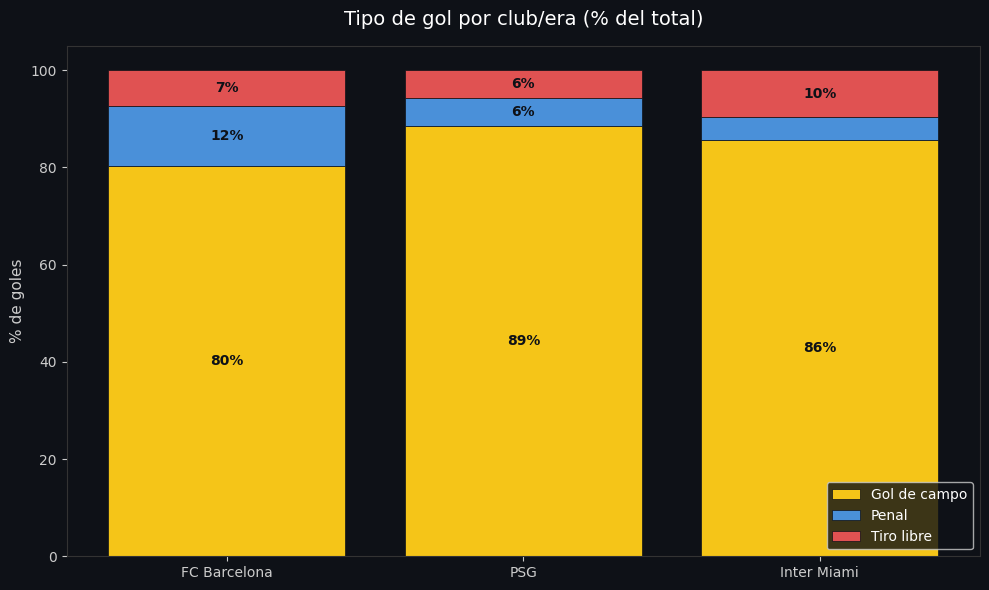

In [26]:
df_club = df[df['Era'].isin(['FC Barcelona', 'PSG', 'Inter Miami'])].copy()
pivot_tipo = df_club.groupby(['Era', 'Tipo_simple']).size().unstack(fill_value=0)
pivot_tipo_pct = pivot_tipo.div(pivot_tipo.sum(axis=1), axis=0) * 100
pivot_tipo_pct = pivot_tipo_pct.reindex(['FC Barcelona', 'PSG', 'Inter Miami'])

fig, ax = plt.subplots(figsize=(10, 6))
tipo_colors = {'Gol de campo': GOLD, 'Penal': BLUE, 'Tiro libre': RED}

bottom = np.zeros(len(pivot_tipo_pct))
for tipo, color in tipo_colors.items():
    if tipo in pivot_tipo_pct.columns:
        vals = pivot_tipo_pct[tipo].values
        bars = ax.bar(pivot_tipo_pct.index, vals, bottom=bottom, label=tipo, color=color, edgecolor='#0e1117', linewidth=0.5)
        for i, (bar, v) in enumerate(zip(bars, vals)):
            if v > 5:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bottom[i] + v/2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=10, color='#0e1117', fontweight='bold')
        bottom += vals

ax.set_title('Tipo de gol por club/era (% del total)', fontsize=14, pad=15)
ax.set_ylabel('% de goles', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('tipo_gol_por_era.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()

## 7. Análisis 5 — Competiciones: ¿dónde brilla más?
Top competiciones por cantidad de goles.

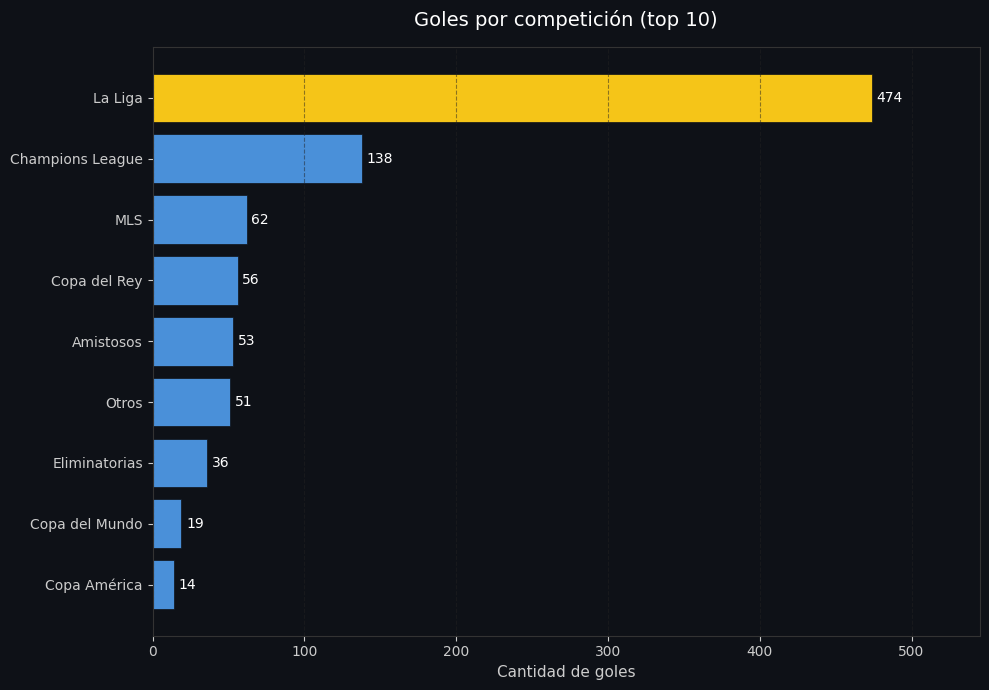

In [27]:
# Simplificar nombres de competiciones
def simplificar_comp(c):
    c = str(c)
    if 'Champions' in c or 'UEFA Champions' in c: return 'Champions League'
    if 'La Liga' in c or 'Liga' in c: return 'La Liga'
    if 'Copa del Rey' in c: return 'Copa del Rey'
    if 'World Cup' in c and 'Qualif' not in c and 'WCQ' not in c: return 'Copa del Mundo'
    if 'Copa América' in c or 'CPA' in c: return 'Copa América'
    if 'Eliminatorias' in c or 'WCQ' in c: return 'Eliminatorias'
    if 'Major League' in c or 'MLS' in c: return 'MLS'
    if 'Amistoso' in c: return 'Amistosos'
    if 'Club World Cup' in c or 'WCT' in c: return 'Club World Cup'
    return 'Otros'

df['Competicion_simple'] = df['Competición'].apply(simplificar_comp)

top_comp = df.groupby('Competicion_simple').size().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [GOLD if v == top_comp.max() else BLUE for v in top_comp.values]
bars = ax.barh(top_comp.index, top_comp.values, color=bar_colors, edgecolor='#0e1117', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', ha='left', fontsize=10)

ax.set_title('Goles por competición (top 10)', fontsize=14, pad=15)
ax.set_xlabel('Cantidad de goles', fontsize=11)
ax.grid(axis='x', zorder=0)
ax.set_xlim(0, top_comp.max() * 1.15)

plt.tight_layout()
plt.savefig('goles_por_competicion.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()

## 8. Análisis 6 — Heatmap mensual: ¿en qué época del año mete más?
Distribución de goles por mes y año — el patrón estacional.

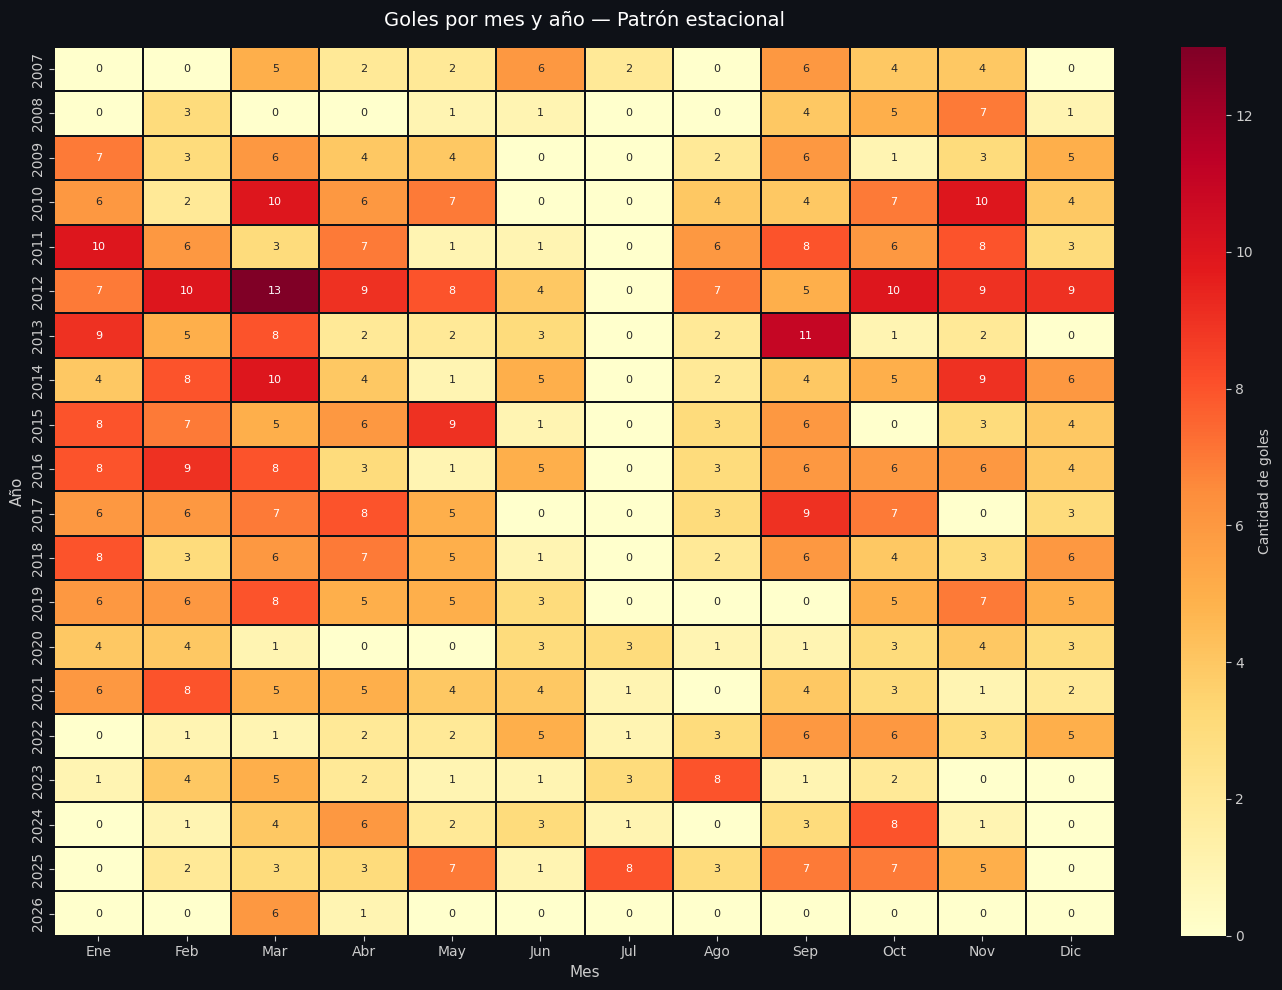

In [28]:
# Solo años con datos significativos (excluyendo primeras temporadas)
df_hm = df[(df['Año'] >= 2007) & df['Mes'].notna() & df['Año'].notna()].copy()
pivot_hm = df_hm.groupby(['Año', 'Mes']).size().unstack(fill_value=0)

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
pivot_hm.columns = [meses[i-1] for i in pivot_hm.columns]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    pivot_hm,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='#0e1117',
    annot=True,
    fmt='d',
    ax=ax,
    cbar_kws={'label': 'Cantidad de goles'},
    annot_kws={'size': 8}
)
ax.set_title('Goles por mes y año — Patrón estacional', fontsize=14, pad=15)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Año', fontsize=11)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('heatmap_mensual.png', dpi=150, bbox_inches='tight', facecolor='#0e1117')
plt.show()

## 9. Conclusiones
Resumen de los hallazgos principales del análisis.

In [29]:
total_goles = len(df)
primer_gol = df['Fecha'].min().strftime('%d/%m/%Y')
ultimo_gol = df['Fecha'].max().strftime('%d/%m/%Y')
años_carrera = df['Año'].max() - df['Año'].min()
media_por_temp = df.groupby('Temporada').size().mean()

goles_barca = len(df[df['Era'] == 'FC Barcelona'])
goles_miami = len(df[df['Era'] == 'Inter Miami'])
goles_psg = len(df[df['Era'] == 'PSG'])
goles_arg = len(df[df['Era'] == 'Selección Argentina'])

pie_izq_pct = (df['Pie'] == 'Pie izquierdo').mean() * 100
franja_max = df['Minuto_num'].dropna().pipe(lambda s: pd.cut(s, bins=[0,15,30,45,60,75,90,120],
                  labels=['1-15','16-30','31-45','46-60','61-75','76-90','90+']).value_counts().idxmax())

print('=' * 55)
print('         ANATOMÍA DE UN GOL DE MESSI — RESUMEN')
print('=' * 55)
print(f'  Total de goles analizados : {total_goles}')
print(f'  Período                   : {primer_gol} → {ultimo_gol}')
print(f'  Años de carrera           : {años_carrera}')
print(f'  Media por temporada       : {media_por_temp:.0f} goles')
print()
print('  Por club/selección:')
print(f'    FC Barcelona            : {goles_barca} goles')
print(f'    PSG                     : {goles_psg} goles')
print(f'    Inter Miami             : {goles_miami} goles')
print(f'    Selección Argentina     : {goles_arg} goles')
print()
print(f'  % goles de zurda          : {pie_izq_pct:.1f}%')
print(f'  Franja de minutos más letal: {franja_max}')
print('=' * 55)

         ANATOMÍA DE UN GOL DE MESSI — RESUMEN
  Total de goles analizados : 903
  Período                   : 01/05/2005 → 04/04/2026
  Años de carrera           : 21
  Media por temporada       : 41 goles

  Por club/selección:
    FC Barcelona            : 669 goles
    PSG                     : 35 goles
    Inter Miami             : 83 goles
    Selección Argentina     : 116 goles

  % goles de zurda          : 83.9%
  Franja de minutos más letal: 76-90


## 10. Próximos pasos (ideas para extender el proyecto)

- [ ] **Análisis de rachas**: períodos sin goles vs rachas
- [ ] **Goles decisivos**: cuántos goles fueron para empatar, ganar o ampliar diferencias
- [ ] **Comparativa con Cristiano**: mismo dataset, ¿quién es más constante?
- [ ] **Modelo predictivo**: ¿se puede predecir el minuto del gol según la competición y el rival?
- [ ] **Streamlit app**: dashboard interactivo donde filtrar por era/competición

---
*Dataset recolectado y análisis realizado por Leandro Corvalan · 2026*  
*Fuente de datos: registro propio*